In [1]:
import pandas as pd   #https://www.kaggle.com/datasets/waqi786/remote-work-and-mental-health
import numpy as np
import math
import seaborn as sns
from scipy import stats
from matplotlib import pyplot as plt

In [34]:
#Import CSV as pandas
data_csv = 'Impact_of_Remote_Work_on_Mental_Health.csv'
df = pd.read_csv(data_csv)

In [36]:
#Check Details
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Employee_ID                        5000 non-null   object
 1   Age                                5000 non-null   int64 
 2   Gender                             5000 non-null   object
 3   Job_Role                           5000 non-null   object
 4   Industry                           5000 non-null   object
 5   Years_of_Experience                5000 non-null   int64 
 6   Work_Location                      5000 non-null   object
 7   Hours_Worked_Per_Week              5000 non-null   int64 
 8   Number_of_Virtual_Meetings         5000 non-null   int64 
 9   Work_Life_Balance_Rating           5000 non-null   int64 
 10  Stress_Level                       5000 non-null   object
 11  Mental_Health_Condition            3804 non-null   object
 12  Access

In [38]:
df.head()

,Employee_ID,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,EMP0001,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,EMP0002,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
2,EMP0003,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,NaN,Poor,North America
3,EMP0004,27,Male,Software Engineer,Finance,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,NaN,Poor,Europe
4,EMP0005,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,NaN,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America


In [40]:
#Narrowing down to only North America 
north_america_df = df[df['Region'] == 'North America']
north_america_df.head()

,Employee_ID,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
2,EMP0003,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,NaN,Poor,North America
4,EMP0005,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,NaN,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America
7,EMP0008,42,Non-binary,Data Scientist,Manufacturing,6,Onsite,54,7,3,Medium,Depression,No,Decrease,5,Satisfied,4,NaN,Average,North America
9,EMP0010,30,Female,HR,IT,28,Hybrid,57,6,1,Low,Depression,Yes,Decrease,2,Neutral,1,Weekly,Poor,North America
13,EMP0014,51,Non-binary,Designer,Manufacturing,5,Hybrid,45,13,1,Low,Anxiety,No,Decrease,2,Satisfied,5,Weekly,Poor,North America


In [42]:
#Check for any duplicates
duplicates = north_america_df.duplicated()
print(duplicates)

2       False
4       False
7       False
9       False
13      False
        ...  
4930    False
4932    False
4938    False
4950    False
4955    False
Length: 777, dtype: bool


In [44]:
#Remove any duplicates
df_na = north_america_df.drop_duplicates()
df_na
print(df_na.head())

   Employee_ID  Age      Gender           Job_Role       Industry  \
2      EMP0003   59  Non-binary  Software Engineer      Education   
4      EMP0005   49        Male              Sales     Consulting   
7      EMP0008   42  Non-binary     Data Scientist  Manufacturing   
9      EMP0010   30      Female                 HR             IT   
13     EMP0014   51  Non-binary           Designer  Manufacturing   

    Years_of_Experience Work_Location  Hours_Worked_Per_Week  \
2                    22        Hybrid                     46   
4                    32        Onsite                     35   
7                     6        Onsite                     54   
9                    28        Hybrid                     57   
13                    5        Hybrid                     45   

    Number_of_Virtual_Meetings  Work_Life_Balance_Rating Stress_Level  \
2                           11                         5       Medium   
4                           12                        

In [46]:
#Checking for null values
df_na.isnull().sum()

Employee_ID                            0
Age                                    0
Gender                                 0
Job_Role                               0
Industry                               0
Years_of_Experience                    0
Work_Location                          0
Hours_Worked_Per_Week                  0
Number_of_Virtual_Meetings             0
Work_Life_Balance_Rating               0
Stress_Level                           0
Mental_Health_Condition              189
Access_to_Mental_Health_Resources      0
Productivity_Change                    0
Social_Isolation_Rating                0
Satisfaction_with_Remote_Work          0
Company_Support_for_Remote_Work        0
Physical_Activity                    260
Sleep_Quality                          0
Region                                 0
dtype: int64

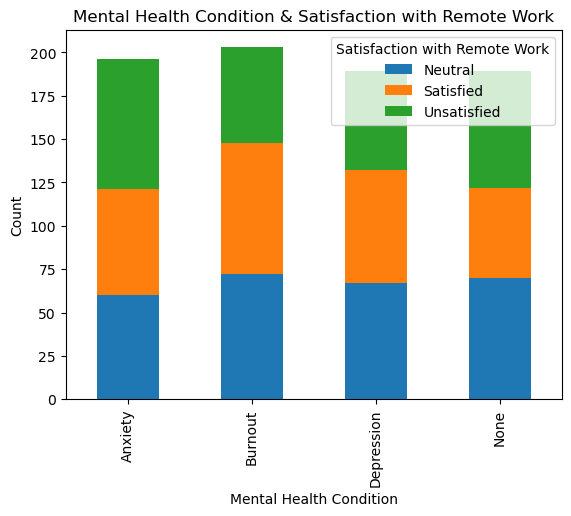

In [58]:
# Mental Health Conditions vs. Satisfaction with Remote Work

#Convert Missing values to 'None' string
df_na['Mental_Health_Condition'] = df_na['Mental_Health_Condition'].fillna('None')

# Define the categories 
categories = ['Anxiety', 'Burnout', 'Depression', 'None']
df_na['Mental_Health_Condition'] = pd.Categorical(df_na['Mental_Health_Condition'], categories=categories, ordered=False)

# Create a crosstab to count occurrences
crosstab = pd.crosstab(df_na['Mental_Health_Condition'], df_na['Satisfaction_with_Remote_Work'], dropna=False)

# Ensure 'None' is included by reindexing
crosstab = crosstab.reindex(categories, fill_value=0)

# Plot the stacked bar chart
crosstab.plot(kind='bar', stacked=True)

plt.title('Mental Health Condition & Satisfaction with Remote Work')
plt.xlabel('Mental Health Condition')
plt.ylabel('Count')
plt.legend(title='Satisfaction with Remote Work')
plt.show()


C:\Anaconda\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


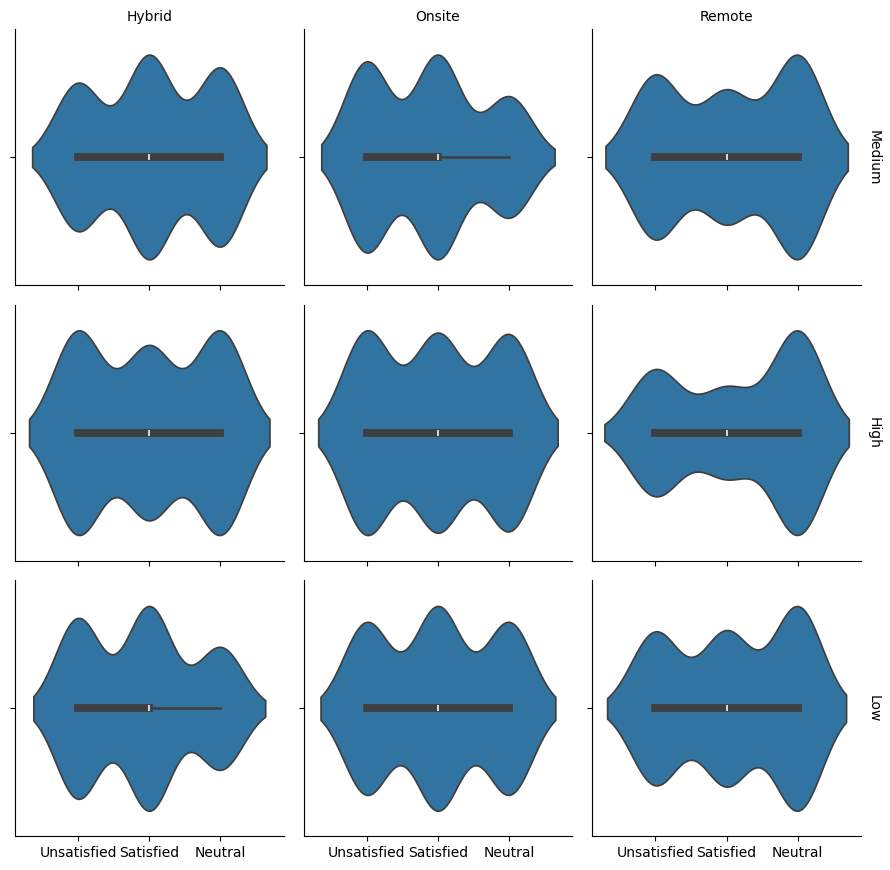

In [49]:
#Stress Levels vs. Remote Work Satisfation in Different Work Locations
# Create a FacetGrid
g = sns.FacetGrid(df_na, col="Work_Location", row="Stress_Level", margin_titles=True)
g.map(sns.violinplot, "Satisfaction_with_Remote_Work")

# Adjust the plot
g.set_axis_labels("")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
plt.show()

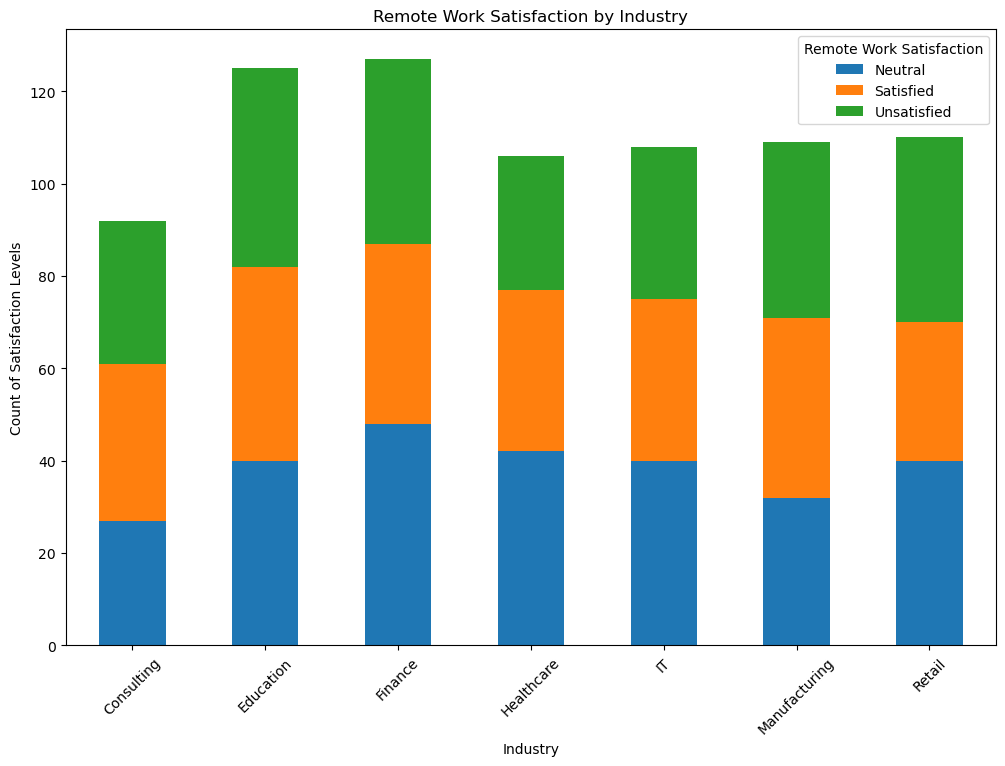

In [51]:
#Stacked Bar Chart of Remote Work Satisfaction by Industry
crosstab = pd.crosstab(df_na['Industry'], df_na['Satisfaction_with_Remote_Work'])

crosstab.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Remote Work Satisfaction by Industry')
plt.xlabel('Industry')
plt.ylabel('Count of Satisfaction Levels')
plt.xticks(rotation=45)
plt.legend(title='Remote Work Satisfaction')
plt.show()